In [1]:
from kan import KAN
import torch
from torch.utils.data import DataLoader, TensorDataset
from MLP2layers import NeuralNetwork, test_loop, train_loop
from torch import nn
import numpy as np
import random

In [2]:
seed = 10
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

device = 'cpu'
targetModel = NeuralNetwork()
layers = list(*targetModel.children())
x = torch.linspace(-5,5,steps=200)[:,None].repeat(1,2)
print(targetModel.state_dict())
# x = torch.randn(1000,2)

OrderedDict({'linear_relu_stack.0.weight': tensor([[-0.0593, -0.0242],
        [-0.2652,  0.1627],
        [-0.4045, -0.1247]]), 'linear_relu_stack.0.bias': tensor([0.2741, 0.6637, 0.1666]), 'linear_relu_stack.2.weight': tensor([[-0.1959,  0.0554, -0.0647]]), 'linear_relu_stack.2.bias': tensor([0.2357])})


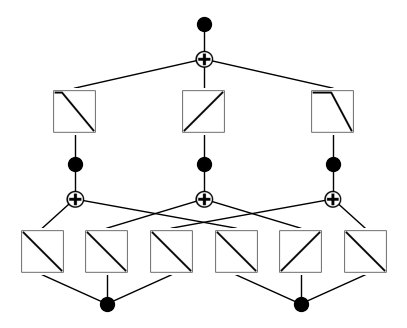

In [3]:
kan = KAN(width=[2,3,1], seed=seed, grid=100, auto_save=False, symbolic_enabled=False)
kan.set_splines_MLPandFuncs(x, modelPartitions=[layers[:1], layers[1:]], func_list = [])
# kan.set_splines_MLPandFuncs(x, modelPartitions=[layers[:1], layers[1:]], func_list = [(lambda x: x**2, 0, 0 ,0)])
# kan.set_splines_MLP(x, modelPartitions=[layers[:1], layers[1:]])
kan.plot(beta=100)

In [4]:
X_kan = torch.randn(10000,2)
y_kan = kan(X_kan).detach()
y_kan_mean = y_kan.numpy().mean()

def rmse(y_true, y_pred):
    return torch.sqrt(torch.mean((y_true - y_pred) ** 2)).item()

In [5]:
train_dataset = TensorDataset(X_kan, y_kan)
test_dataset = TensorDataset(X_kan, y_kan)

train_dataLoader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_dataLoader = DataLoader(test_dataset, batch_size=16, shuffle=False)

device = "cpu"

model = NeuralNetwork()
loss_fn = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=1e-2)
# optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)

epochs = 20
rmse_history = []
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train_loop(train_dataLoader, model, loss_fn, optimizer)
    rmse_iter = test_loop(test_dataLoader, model, loss_fn)
    print(f"RMSE: {rmse_iter:>8f}\n")
    rmse_history.append(rmse_iter)



Epoch 1
-------------------------------
Test loss: 0.003404
RMSE: 0.053468

Epoch 2
-------------------------------
Test loss: 0.002195
RMSE: 0.043404

Epoch 3
-------------------------------
Test loss: 0.001875
RMSE: 0.040408

Epoch 4
-------------------------------
Test loss: 0.001735
RMSE: 0.038938

Epoch 5
-------------------------------
Test loss: 0.001645
RMSE: 0.038161

Epoch 6
-------------------------------
Test loss: 0.001582
RMSE: 0.037357

Epoch 7
-------------------------------
Test loss: 0.001533
RMSE: 0.036835

Epoch 8
-------------------------------
Test loss: 0.001498
RMSE: 0.036355

Epoch 9
-------------------------------
Test loss: 0.001468
RMSE: 0.036380

Epoch 10
-------------------------------
Test loss: 0.001433
RMSE: 0.035773

Epoch 11
-------------------------------
Test loss: 0.001407
RMSE: 0.035538

Epoch 12
-------------------------------
Test loss: 0.001385
RMSE: 0.035343

Epoch 13
-------------------------------
Test loss: 0.001364
RMSE: 0.035047

Epoch 14

In [6]:
model.eval()
y_mlp_pred = model(X_kan).detach()
print(rmse(y_kan, y_mlp_pred))

0.03562470152974129


0.041097622364759445


| train_loss: 4.33e-02 | test_loss: 4.33e-02 | reg: 1.05e+00 | : 100%|█| 20/20 [00:08<00:00,  2.28it


0.04331742599606514


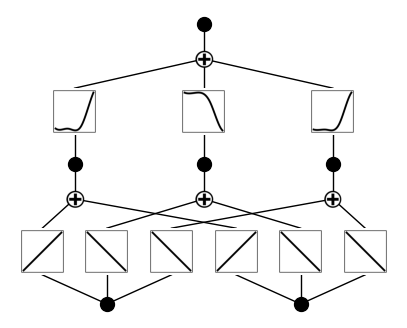

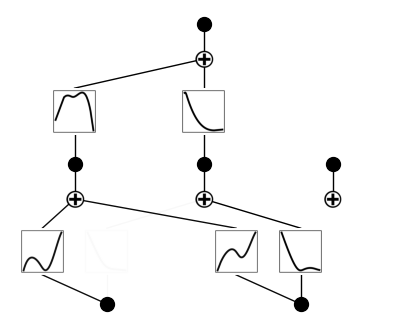

In [7]:
new_layers = list(*model.children())
kan2 = KAN(width=[2,3,1], seed=seed, grid=3, symbolic_enabled=False, auto_save=False)
kan2.set_splines_MLP(x, modelPartitions=[new_layers[:1], new_layers[1:]])
kan2.plot(beta=100)
y_kan2_pred = kan2(X_kan).detach()
kan2_rmse = rmse(y_kan, y_kan2_pred)   
print(kan2_rmse)


dataset1 = {'train_input':X_kan, 'train_label':y_kan, 'test_input': X_kan, 'test_label':y_kan}
# f = lambda x: torch.exp(torch.sin(torch.pi*x[:,[0]]) + x[:,[1]]**2)
# dataset = create_dataset(f, n_var=2, device=device)
# kan2(dataset1['train_input'])
kanFitLoss = kan2.fit(dataset1, opt="LBFGS", steps=20, lamb=0.01)
kan2.plot(beta=100)
y_kan2_pred_afterFit = kan2(X_kan).detach()
print(rmse(y_kan, y_kan2_pred_afterFit))

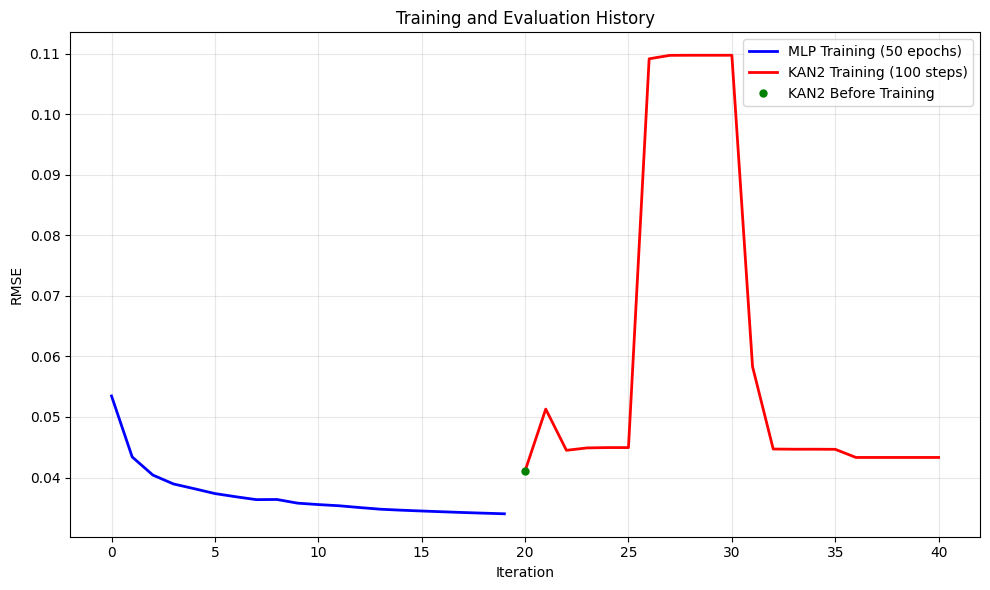

In [8]:
kanLossHistory = [x.item() for x in kanFitLoss['test_loss']]
full_history = [*rmse_history, kan2_rmse, *kanLossHistory]
import matplotlib.pyplot as plt
# Create the plot with different colors for different segments
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(range(len(rmse_history)), rmse_history, color='blue', linewidth=2, label='MLP Training (50 epochs)')

ax.plot(range(len(rmse_history), len(full_history)), [kan2_rmse, *kanLossHistory], color='red', linewidth=2, label='KAN2 Training (100 steps)')

ax.plot(len(rmse_history), kan2_rmse, 'o', color='green', markersize=5, label='KAN2 Before Training')

ax.set_xlabel('Iteration')
ax.set_ylabel('RMSE')
ax.set_title('Training and Evaluation History')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

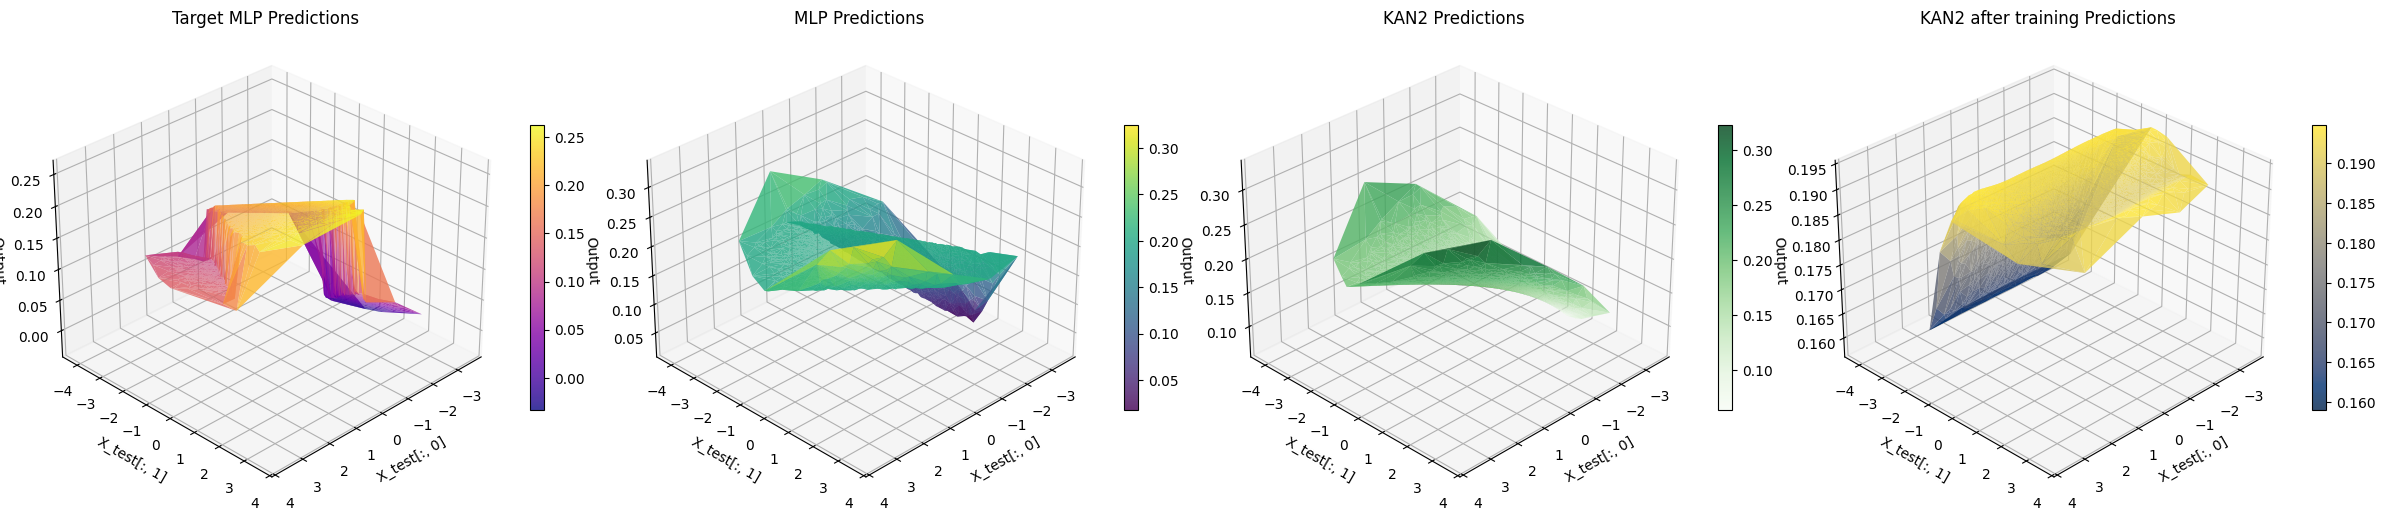

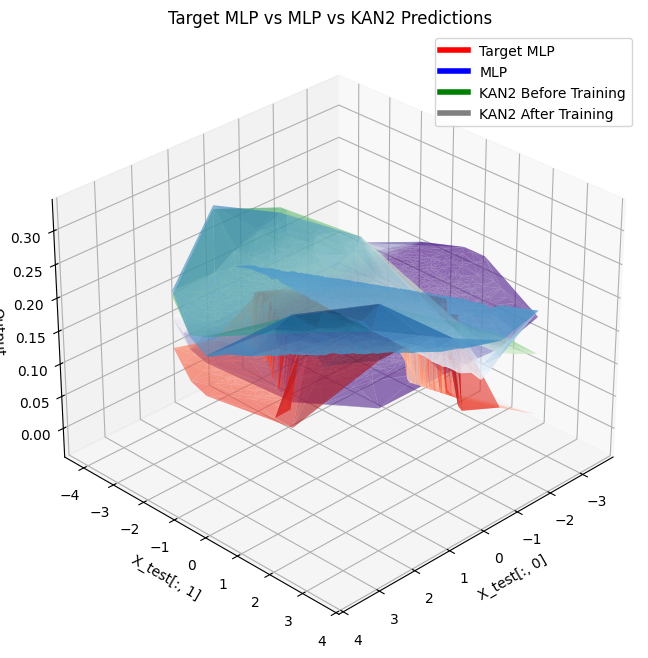

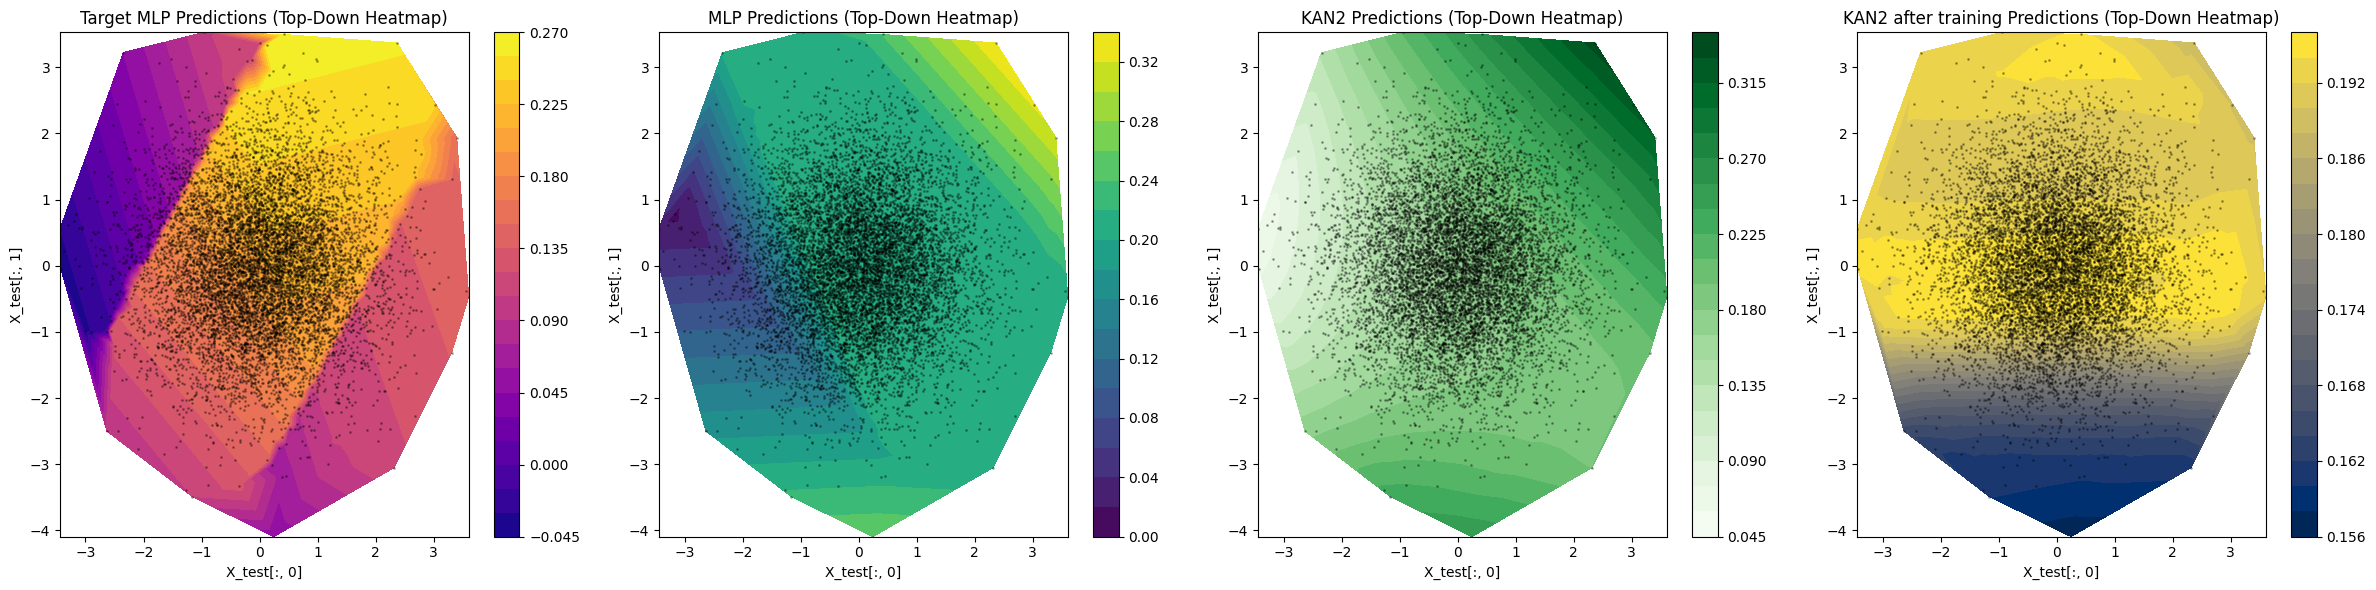

In [9]:
import matplotlib.pyplot as plt
import matplotlib.tri as mtri
from matplotlib.lines import Line2D
# Get predictions from both models
X_plot = X_kan.numpy()
y_plot = y_kan.numpy()
model.eval()
with torch.no_grad():
    X_test_tensor = torch.from_numpy(X_plot).float()
    
    y_target_mlp_np = y_plot.flatten()

    y_mlp_pred_np = y_mlp_pred.numpy().flatten()
    y_kan2_pred_np = y_kan2_pred.numpy().flatten()

    y_kan2_pred_afterFit_np = y_kan2_pred_afterFit.numpy().flatten()

# Set viewing angles (in degrees)
elevation = 30  # vertical angle
azimuth = 45    # horizontal rotation

# Use triangulation for scattered data (no griddata)
triang = mtri.Triangulation(X_plot[:, 0], X_plot[:, 1])

# Create surface plots - KAN, MLP, and KAN2
fig = plt.figure(figsize=(24, 6))

# Plot 1: Target MLP predictions
ax1 = fig.add_subplot(141, projection='3d')
surf1 = ax1.plot_trisurf(triang, y_target_mlp_np, cmap='plasma', alpha=0.8, linewidth=0.2, antialiased=True)
ax1.set_xlabel('X_test[:, 0]')
ax1.set_ylabel('X_test[:, 1]')
ax1.set_zlabel('Output')
ax1.set_title('Target MLP Predictions')
ax1.view_init(elev=elevation, azim=azimuth)
fig.colorbar(surf1, ax=ax1, shrink=0.5)

# Plot 2: MLP predictions
ax2 = fig.add_subplot(142, projection='3d')
surf2 = ax2.plot_trisurf(triang, y_mlp_pred_np, cmap='viridis', alpha=0.8, linewidth=0.2, antialiased=True)
ax2.set_xlabel('X_test[:, 0]')
ax2.set_ylabel('X_test[:, 1]')
ax2.set_zlabel('Output')
ax2.set_title('MLP Predictions')
ax2.view_init(elev=elevation, azim=azimuth)
fig.colorbar(surf2, ax=ax2, shrink=0.5)

#plot 3: KAN2 before training predictions
ax3 = fig.add_subplot(143, projection='3d')
surf3 = ax3.plot_trisurf(triang, y_kan2_pred_np, cmap='Greens', alpha=0.8, linewidth=0.2, antialiased=True)
ax3.set_xlabel('X_test[:, 0]')
ax3.set_ylabel('X_test[:, 1]')
ax3.set_zlabel('Output')
ax3.set_title('KAN2 Predictions')
ax3.view_init(elev=elevation, azim=azimuth)
fig.colorbar(surf3, ax=ax3, shrink=0.5)

# Plot 4: KAN2 after training predictions
ax4 = fig.add_subplot(144, projection='3d')
surf4 = ax4.plot_trisurf(triang, y_kan2_pred_afterFit_np, cmap='cividis', alpha=0.8, linewidth=0.2, antialiased=True)
ax4.set_xlabel('X_test[:, 0]')
ax4.set_ylabel('X_test[:, 1]')
ax4.set_zlabel('Output')
ax4.set_title('KAN2 after training Predictions')
ax4.view_init(elev=elevation, azim=azimuth)
fig.colorbar(surf4, ax=ax4, shrink=0.5)

plt.tight_layout()
plt.show()

# Combined plot showing difference (tri-surf overlays)
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.plot_trisurf(triang, y_target_mlp_np, cmap='Reds', alpha=0.6)
ax.plot_trisurf(triang, y_mlp_pred_np, cmap='Blues', alpha=0.6)
ax.plot_trisurf(triang, y_kan2_pred_np, cmap='Greens', alpha=0.6)
ax.plot_trisurf(triang, y_kan2_pred_afterFit_np, cmap='Purples', alpha=0.6)
ax.set_xlabel('X_test[:, 0]')
ax.set_ylabel('X_test[:, 1]')
ax.set_zlabel('Output')
ax.set_title('Target MLP vs MLP vs KAN2 Predictions')
ax.view_init(elev=elevation, azim=azimuth)

# Create custom legend
legend_elements = [
    Line2D([0], [0], color='red', lw=4, label='Target MLP'),
    Line2D([0], [0], color='blue', lw=4, label='MLP'),
    Line2D([0], [0], color='green', lw=4, label='KAN2 Before Training'),
    Line2D([0], [0], color='grey', lw=4, label='KAN2 After Training')
]
ax.legend(handles=legend_elements, loc='upper right')

plt.show()

# Create top-down heatmap views using tricontourf
fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(24, 6))

# Target MLP heatmap
im1 = ax1.tricontourf(triang, y_target_mlp_np, levels=20, cmap='plasma')
ax1.scatter(X_plot[:, 0], X_plot[:, 1], c='black', s=1, alpha=0.3, label='Data Points')
ax1.set_xlabel('X_test[:, 0]')
ax1.set_ylabel('X_test[:, 1]')
ax1.set_title('Target MLP Predictions (Top-Down Heatmap)')
fig.colorbar(im1, ax=ax1)

# MLP heatmap
im2 = ax2.tricontourf(triang, y_mlp_pred_np, levels=20, cmap='viridis')
ax2.scatter(X_plot[:, 0], X_plot[:, 1], c='black', s=1, alpha=0.3, label='Data Points')
ax2.set_xlabel('X_test[:, 0]')
ax2.set_ylabel('X_test[:, 1]')
ax2.set_title('MLP Predictions (Top-Down Heatmap)')
fig.colorbar(im2, ax=ax2)

# KAN2 heatmap
im3 = ax3.tricontourf(triang, y_kan2_pred_np, levels=20, cmap='Greens')
ax3.scatter(X_plot[:, 0], X_plot[:, 1], c='black', s=1, alpha=0.3, label='Data Points')
ax3.set_xlabel('X_test[:, 0]')
ax3.set_ylabel('X_test[:, 1]')
ax3.set_title('KAN2 Predictions (Top-Down Heatmap)')
fig.colorbar(im3, ax=ax3)

# KAN2 after training heatmap
im4 = ax4.tricontourf(triang, y_kan2_pred_afterFit_np, levels=20, cmap='cividis')
ax4.scatter(X_plot[:, 0], X_plot[:, 1], c='black', s=1, alpha=0.3, label='Data Points')
ax4.set_xlabel('X_test[:, 0]')
ax4.set_ylabel('X_test[:, 1]')
ax4.set_title('KAN2 after training Predictions (Top-Down Heatmap)')
fig.colorbar(im4, ax=ax4)

plt.tight_layout()
plt.show()
